In [2]:
import pandas as pd 
import matplotlib.pyplot as plt
from config import get_engine 

engine=get_engine()

Connected to database: ecommerce_analytics 


In [3]:
# Load Cleaned Table 
clean_df = pd.read_sql("SELECT * FROM clean_orders", engine)
rfm_df=pd.read_sql("Select * from customer_rfm",engine)
churn_df=pd.read_sql("Select * from customer_churn",engine)
print("Cleaned data loaded successfully")
print("Cleaned dataset shape:", clean_df.shape)
print(clean_df.head())

Cleaned data loaded successfully
Cleaned dataset shape: (17107, 33)
   row_id       order_id order_date  ship_date       ship_mode customer_id  \
0       1  IND-ORD-00001 2022-04-21 2022-04-26  Standard Class   CUST-0341   
1       2  IND-ORD-00001 2022-04-21 2022-04-27  Standard Class   CUST-0341   
2       3  IND-ORD-00002 2023-04-30 2023-05-07  Standard Class   CUST-0167   
3       4  IND-ORD-00002 2023-04-30 2023-05-05  Standard Class   CUST-0167   
4       5  IND-ORD-00003 2024-04-11 2024-04-16    Second Class   CUST-0545   

  product_id  quantity  discount      sales  ...  invalid_order_date  \
0       P019         2       0.2    1671.60  ...               False   
1       P020         6       0.0    3647.05  ...               False   
2       P025         1       0.0    7519.46  ...               False   
3       P015         4       0.0    3855.87  ...               False   
4       P004         2       0.0  107870.72  ...               False   

  invalid_ship_date missing_cu

In [4]:
# Post Cleaning Validation 
print("\n==============================")
print("CLEANED DATA INFO")
print("==============================")
print(clean_df.info())

print("\n==============================")
print("MISSING VALUES AFTER CLEANING")
print("==============================")
print(clean_df.isnull().sum())

print("\n==============================")
print("DUPLICATES AFTER CLEANING")
print("==============================")
print(clean_df.duplicated().sum())

print("\n==============================")
print("NUMERICAL SUMMARY AFTER CLEANING")
print("==============================")
print(clean_df[["sales", "profit", "quantity", "discount", "profit_margin", "ship_days"]].describe())


CLEANED DATA INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17107 entries, 0 to 17106
Data columns (total 33 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   row_id                    17107 non-null  int64         
 1   order_id                  17107 non-null  object        
 2   order_date                17107 non-null  datetime64[ns]
 3   ship_date                 17107 non-null  datetime64[ns]
 4   ship_mode                 17107 non-null  object        
 5   customer_id               17107 non-null  object        
 6   product_id                17107 non-null  object        
 7   quantity                  17107 non-null  int64         
 8   discount                  17107 non-null  float64       
 9   sales                     17107 non-null  float64       
 10  profit                    17107 non-null  float64       
 11  payment_mode              17107 non-null  object        
 12 

In [5]:
#EDA Columns
def discount_band(value):
    if value == 0:
        return "No Discount"
    elif value <= 0.10:
        return "Low Discount"
    elif value <= 0.20:
        return "Medium Discount"
    else:
        return "High Discount"


def shipping_speed(days):
    if days <= 2:
        return "Fast Shipping"
    elif days <= 5:
        return "Normal Shipping"
    else:
        return "Slow Shipping"


clean_df["discount_band"] = clean_df["discount"].apply(discount_band)
clean_df["shipping_speed"] = clean_df["ship_days"].apply(shipping_speed)
clean_df["profit_status"] = clean_df["profit"].apply(lambda x: "Profit" if x >= 0 else "Loss")

In [6]:
#Discount and Shipping Analysis

# Display floats in normal format instead of scientific notation
pd.options.display.float_format = '{:,.2f}'.format

discount_summary = (
    clean_df.groupby("discount_band")
    .agg(
        total_sales=("sales", "sum"),
        total_profit=("profit", "sum"),
        total_orders=("order_id", "nunique"),
        avg_discount=("discount", "mean")
    )
    .sort_values("total_sales", ascending=False)
)

shipping_summary = (
    clean_df.groupby("shipping_speed")
    .agg(
        total_sales=("sales", "sum"),
        total_profit=("profit", "sum"),
        total_orders=("order_id", "nunique"),
        avg_ship_days=("ship_days", "mean")
    )
    .sort_values("total_sales", ascending=False)
)

profit_status_summary = (
    clean_df.groupby("profit_status")
    .agg(
        total_rows=("row_id", "count"),
        total_sales=("sales", "sum"),
        total_profit=("profit", "sum"),
        total_orders=("order_id", "nunique")
    )
    .sort_values("total_profit", ascending=False)
)

print("\n==============================")
print("DISCOUNT SUMMARY")
print("==============================")
print(discount_summary)

print("\n==============================")
print("SHIPPING SUMMARY")
print("==============================")
print(shipping_summary)

print("\n==============================")
print("PROFIT STATUS SUMMARY")
print("==============================")
print(profit_status_summary)


DISCOUNT SUMMARY
                   total_sales  total_profit  total_orders  avg_discount
discount_band                                                           
No Discount     184,444,538.09 22,268,150.39          5375          0.00
Low Discount    154,626,563.62 14,854,069.43          5057          0.07
Medium Discount  76,185,085.81  4,901,492.95          3096          0.17
High Discount    25,465,744.46    661,421.70          1285          0.27

SHIPPING SUMMARY
                   total_sales  total_profit  total_orders  avg_ship_days
shipping_speed                                                           
Normal Shipping 223,555,401.82 21,810,375.91          6906           3.73
Fast Shipping   160,927,684.68 15,416,846.54          5288           1.64
Slow Shipping    56,238,845.48  5,457,912.02          1985           6.85

PROFIT STATUS SUMMARY
               total_rows    total_sales  total_profit  total_orders
profit_status                                                   

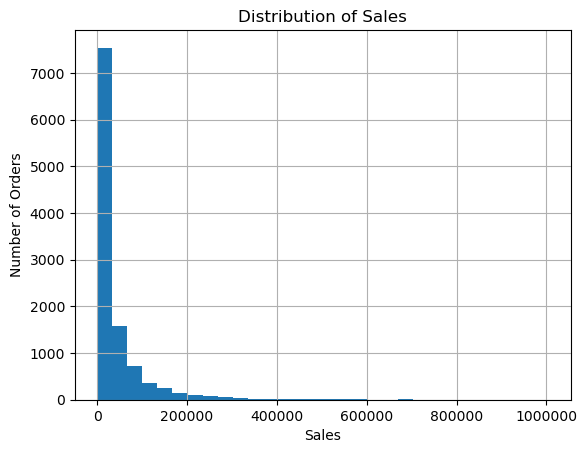

In [7]:
#Sales Distribution Histogram
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

order_sales = clean_df.groupby("order_id")["sales"].sum()

ax = order_sales.hist(bins=30)

plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Number of Orders")

ax.ticklabel_format(style='plain', axis='x')

plt.show()

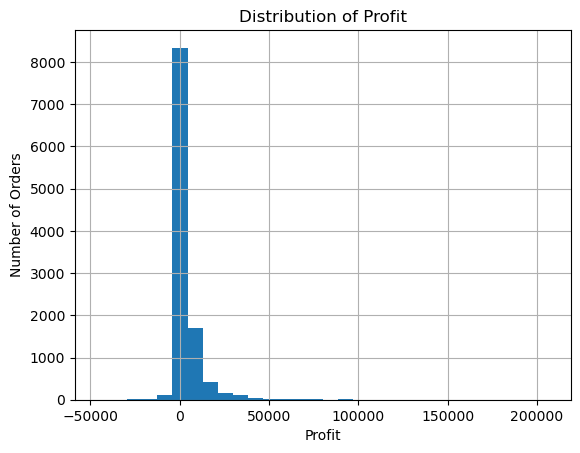

In [8]:
#Profit Distribution Histogram
# Profit per distinct order
order_profit = (
    clean_df
    .groupby("order_id")["profit"]
    .sum()
)

# Histogram
ax = order_profit.hist(bins=30)

plt.title("Distribution of Profit")
plt.xlabel("Profit")
plt.ylabel("Number of Orders")

# Show regular numbers instead of scientific notation
ax.ticklabel_format(style='plain', axis='x')

plt.show()

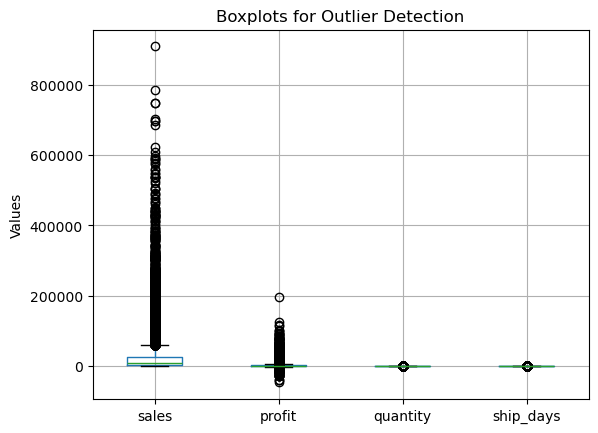

In [9]:
#Boxplots for outlier Detection 
import matplotlib.pyplot as plt

columns = ["sales", "profit", "quantity", "ship_days"]

clean_df.boxplot(column=columns)

plt.title("Boxplots for Outlier Detection")
plt.ylabel("Values")

plt.show()

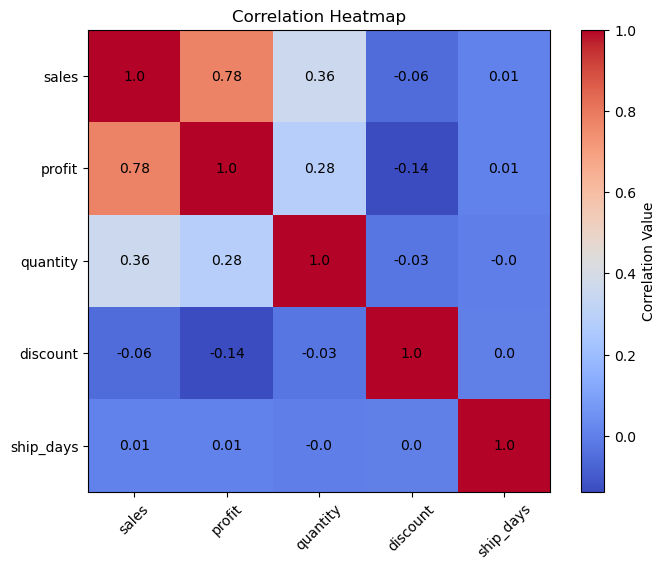

In [10]:
#Heatmap for Correlation
corr = clean_df[
    ["sales", "profit", "quantity", "discount", "ship_days"]
].corr()

plt.figure(figsize=(8, 6))

plt.imshow(corr, cmap="coolwarm", interpolation="nearest")
plt.colorbar(label="Correlation Value")

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)

# Add values inside boxes
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, round(corr.iloc[i, j], 2),
                 ha="center", va="center")

plt.title("Correlation Heatmap")

plt.show()

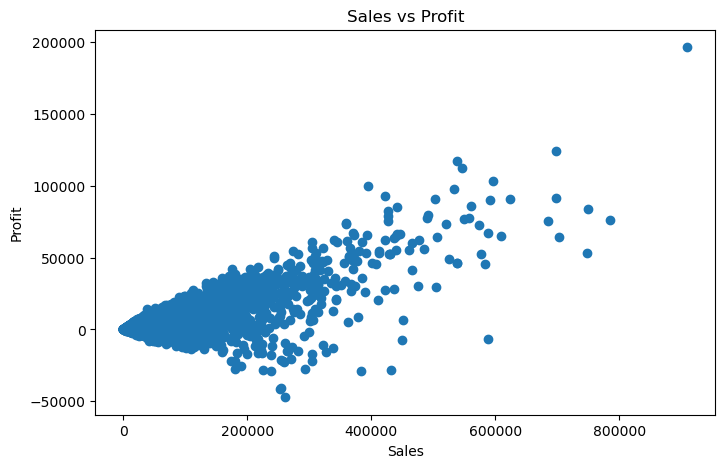

In [11]:
#Scatterplot for relationship between sales and profit 
plt.figure(figsize=(8, 5))

plt.scatter(clean_df["sales"], clean_df["profit"])

plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")

plt.ticklabel_format(style='plain', axis='x')
plt.ticklabel_format(style='plain', axis='y')

plt.show()

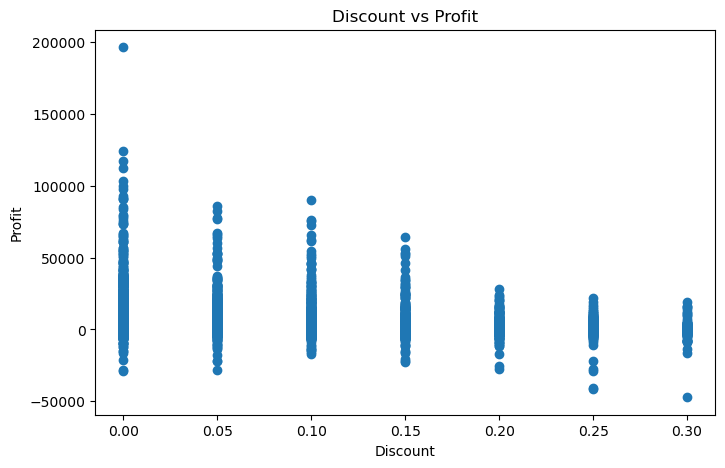

In [12]:
#
plt.figure(figsize=(8, 5))

plt.scatter(clean_df["discount"], clean_df["profit"])

plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.ticklabel_format(style='plain', axis='y')

plt.show()

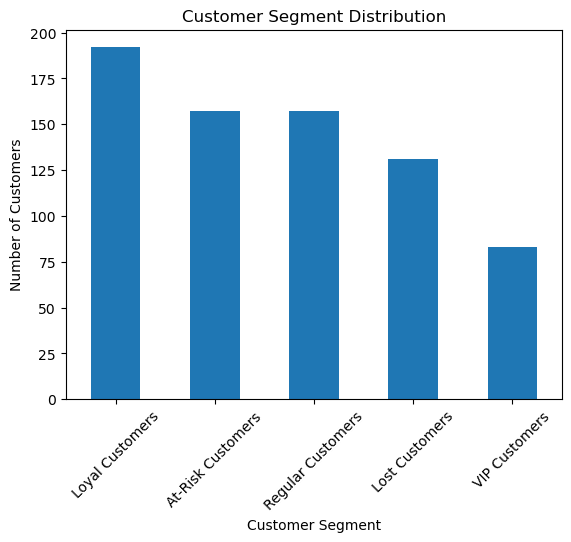

In [13]:
import matplotlib.pyplot as plt

# Count customers in each segment
segment_count = rfm_df["customer_segment"].value_counts()

# Bar chart
ax = segment_count.plot(kind="bar")

plt.title("Customer Segment Distribution")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

plt.xticks(rotation=45)
plt.show()

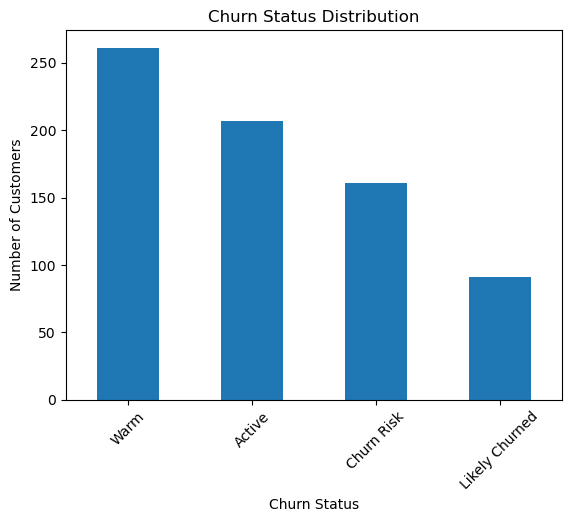

In [14]:
# Count customers in each churn status
churn_count = churn_df["churn_status"].value_counts()

# Bar chart
ax = churn_count.plot(kind="bar")

plt.title("Churn Status Distribution")
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")

plt.xticks(rotation=45)
plt.show()

In [15]:
%run pipepline/

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,product_id,quantity,discount,sales,...,missing_product_details,profit_margin,invalid_discount,order_year,order_month,ship_days,negative_ship_days,discount_band,shipping_speed,profit_status
0,1,IND-ORD-00001,2022-04-21,2022-04-26,Standard Class,CUST-0341,P019,2,0.20,"1,671.60",...,False,0.22,False,2022,2022-04,5,False,Medium Discount,Normal Shipping,Profit
1,2,IND-ORD-00001,2022-04-21,2022-04-27,Standard Class,CUST-0341,P020,6,0.00,"3,647.05",...,False,0.31,False,2022,2022-04,6,False,No Discount,Slow Shipping,Profit
2,3,IND-ORD-00002,2023-04-30,2023-05-07,Standard Class,CUST-0167,P025,1,0.00,"7,519.46",...,False,0.18,False,2023,2023-04,7,False,No Discount,Slow Shipping,Profit
3,4,IND-ORD-00002,2023-04-30,2023-05-05,Standard Class,CUST-0167,P015,4,0.00,"3,855.87",...,False,0.21,False,2023,2023-04,5,False,No Discount,Normal Shipping,Profit
4,5,IND-ORD-00003,2024-04-11,2024-04-16,Second Class,CUST-0545,P004,2,0.00,"107,870.72",...,False,0.15,False,2024,2024-04,5,False,No Discount,Normal Shipping,Profit


In [1]:
import pandas as pd
from config import get_engine

engine = get_engine()

clean_orders = pd.read_sql("SELECT * FROM clean_orders", engine)
customer_rfm = pd.read_sql("SELECT * FROM customer_rfm", engine)
customer_churn = pd.read_sql("SELECT * FROM customer_churn", engine)

clean_orders.to_csv(r"C:\Users\asus\clean_orders.csv", index=False)
customer_rfm.to_csv(r"C:\Users\asus\customer_rfm.csv", index=False)
customer_churn.to_csv(r"C:\Users\asus\customer_churn.csv", index=False)

print("Cleaned CSV files exported successfully")

Connected to database: ecommerce_analytics 
Cleaned CSV files exported successfully


In [2]:
import pandas as pd
from config import get_engine

engine = get_engine()

clean_orders = pd.read_sql("SELECT * FROM clean_orders", engine)
customer_rfm = pd.read_sql("SELECT * FROM customer_rfm", engine)
customer_churn = pd.read_sql("SELECT * FROM customer_churn", engine)

clean_orders.to_csv(r"C:\Users\asus\clean_orders.csv", index=False)
customer_rfm.to_csv(r"C:\Users\asus\customer_rfm.csv", index=False)
customer_churn.to_csv(r"C:\Users\asus\customer_churn.csv", index=False)

print("CSV files exported successfully")

Connected to database: ecommerce_analytics 
CSV files exported successfully
